# 物体検出

In [37]:
from ultralytics import YOLO
import cv2
import numpy as np

In [ ]:
# model = YOLO("models/yolov8n.pt")
# model = YOLO("models/yolo11n.pt")
model = YOLO("models/finetuned_yolo.pt")

# model_name = "yolov8n"
# model_name = "yolo11n"
model_name = "finetuned"

In [39]:
def iou(boxA, boxB):
    # box: [x1,y1,x2,y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    if inter <= 0:
        return 0.0
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter + 1e-9)

In [40]:
def extract_occupancy_from_image(
    image_bgr: np.ndarray,
    nms_iou: float = 0.7,
    conf: float = 0.25,
    class_ids: list[int] | None = None,  # Noneの場合は全クラス検出
) -> dict:
    """YOLOで物体検出を行い、結果を返す"""
    results = model.predict(
        source=image_bgr,
        iou=nms_iou,
        conf=conf,
        classes=class_ids,
        verbose=False,
    )[0]

    # 結果確認
    print(f"results.names: {results.names}")

    boxes = results.boxes
    if boxes is None or len(boxes) == 0:
        return {
            "detections": [],
        }

    detections = []

    for b in boxes:
        cls_id = int(b.cls[0])
        xyxy = b.xyxy[0].cpu().numpy().astype(float).tolist()
        score = float(b.conf[0])
        cls_name = results.names.get(cls_id, f"class_{cls_id}")

        detections.append({
            "class_id": cls_id,
            "class_name": cls_name,
            "box": xyxy,
            "score": score,
        })

    return {
        "detections": detections,
    }

In [41]:
def draw_debug(image_bgr: np.ndarray, occupancy: dict) -> np.ndarray:
    img = image_bgr.copy()

    # クラスごとに色を定義
    class_colors = {
        0: (255, 0, 0),    # person: 青
        56: (0, 255, 0),   # chair: 緑
        # 他のクラスはランダムな色
    }

    for i, det in enumerate(occupancy["detections"]):
        x1, y1, x2, y2 = map(int, det["box"])
        cls_id = det["class_id"]
        cls_name = det["class_name"]
        score = det["score"]

        # 色を取得（定義されていない場合はランダム）
        color = class_colors.get(cls_id, (
            (cls_id * 50) % 255,
            (cls_id * 100) % 255,
            (cls_id * 150) % 255,
        ))

        # バウンディングボックス
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # ラベル（クラス名 + スコア）
        text = f"{cls_name} {score:.2f}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.0
        position = (x1, max(0, y1 - 8))

        # 黒縁取り
        cv2.putText(img, text, position, font, font_scale, (0, 0, 0), 4)
        # カラー文字
        cv2.putText(img, text, position, font, font_scale, color, 2)

    # サマリー情報
    summary_text = f"Total detections: {len(occupancy['detections'])}"

    # 背景矩形
    cv2.rectangle(img, (5, 5), (400, 50), (0, 0, 0), -1)

    # テキスト
    cv2.putText(
        img,
        summary_text,
        (10, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 255),
        2,
    )

    return img

In [42]:
import json
import pathlib

import matplotlib.pyplot as plt

def build_occ(
    input_dir: str,
    output_dir: str,
    file_name: str,
    nms_iou: float,
    conf: float,
    class_ids: list[int] | None = None,
) -> None:
    # 画像読み込み BGR
    img = cv2.imread(str(pathlib.Path(input_dir) / f"{file_name}.jpg"))
    occ = extract_occupancy_from_image(
        img,
        nms_iou=nms_iou,
        conf=conf,
        class_ids=class_ids,
    )
    # 出力ディレクトリを作成
    class_ids_str = "_".join(map(str, class_ids)) if class_ids else "all"
    output_subdir = pathlib.Path(output_dir) / f"conf{conf}_iou{nms_iou}_classes{class_ids_str}"
    output_subdir.mkdir(parents=True, exist_ok=True)
    # occ jsonで保存
    occ_json_path = output_subdir / f"{file_name}_occ.json"
    with open(occ_json_path, "w") as f:
        json.dump(occ, f, indent=2)
    debug = draw_debug(img, occ)
    # Notebook表示と保存
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    # 先に保存
    debug_img_path = output_subdir / f"{file_name}_debug.png"
    print(debug_img_path)
    plt.savefig(debug_img_path, bbox_inches='tight', dpi=150)
    # その後に表示
    plt.show()

results.names: {0: 'empty_seat', 1: 'occupied_seat'}
datasets/outputs/finetuned/conf0.1_iou0.05_classesall/sample1_debug.png


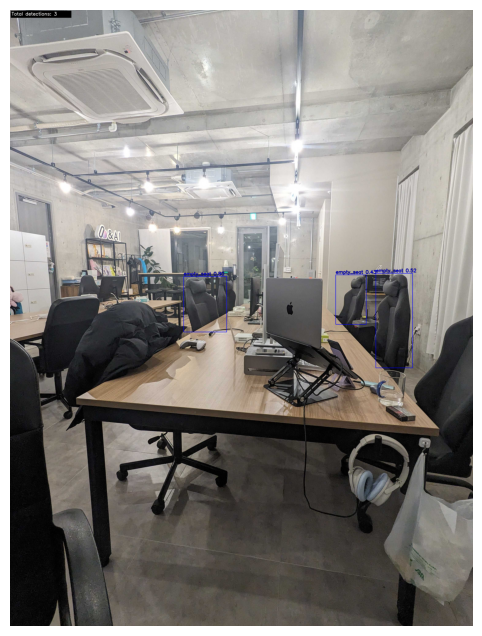

In [43]:
build_occ(
    input_dir = "datasets/test",
    output_dir = f"datasets/outputs/{model_name}",
    file_name = "sample1",
    nms_iou=0.05,
    conf = 0.1,
    # class_ids=[],
    # class_ids=[0, 56],
)

results.names: {0: 'empty_seat', 1: 'occupied_seat'}
datasets/outputs/finetuned/conf0.1_iou0.05_classesall/sample2_debug.png


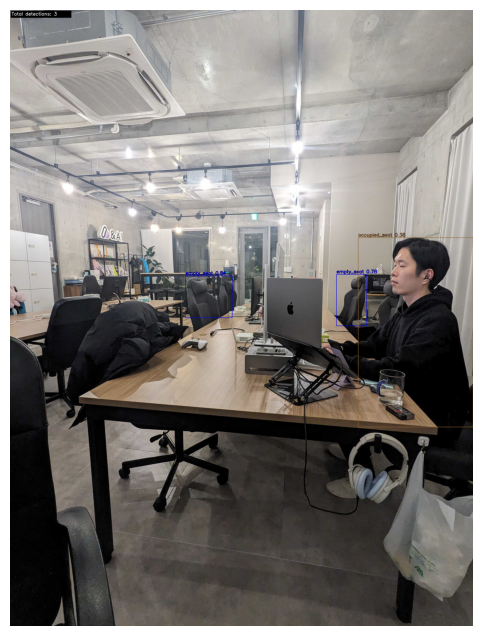

In [44]:
build_occ(
    input_dir = "datasets/test",
    output_dir = f"datasets/outputs/{model_name}",
    file_name = "sample2",
    nms_iou=0.05,
    conf = 0.1,
    # class_ids=[],
    # class_ids=[0, 56],
)

results.names: {0: 'empty_seat', 1: 'occupied_seat'}
datasets/outputs/finetuned/conf0.1_iou0.05_classesall/sample3_debug.png


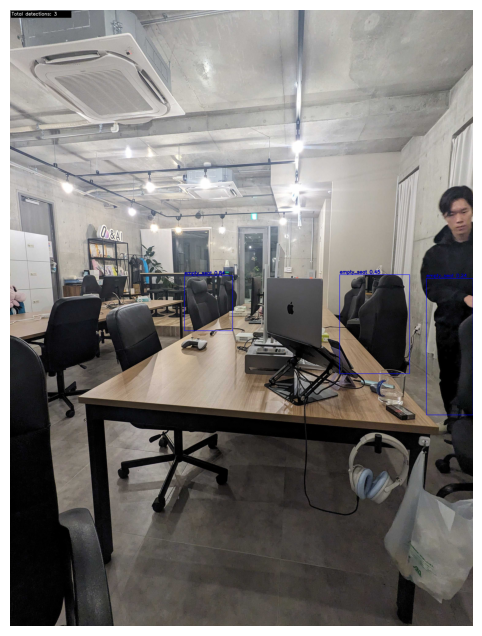

In [45]:
build_occ(
    input_dir = "datasets/test",
    output_dir = f"datasets/outputs/{model_name}",
    file_name = "sample3",
    nms_iou=0.05,
    conf = 0.1,
    # class_ids=[],
    # class_ids=[0, 56],
)

results.names: {0: 'empty_seat', 1: 'occupied_seat'}
datasets/outputs/finetuned/conf0.1_iou0.05_classesall/sample4_debug.png


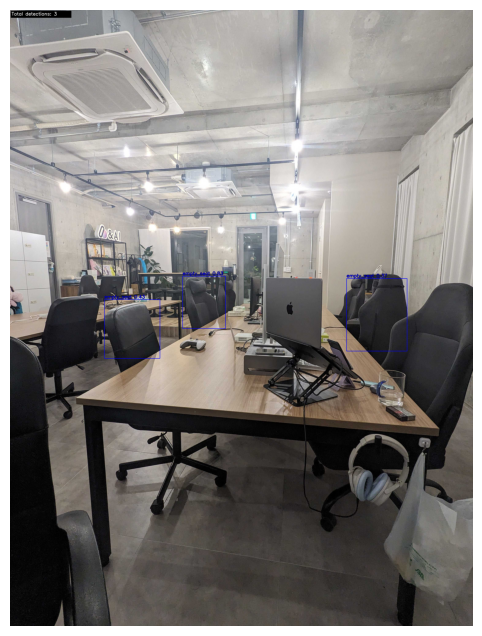

In [46]:
build_occ(
    input_dir = "datasets/test",
    output_dir = f"datasets/outputs/{model_name}",
    file_name = "sample4",
    nms_iou=0.05,
    conf = 0.1,
    # class_ids=[],
    # class_ids=[0, 56],
)